In [ ]:
#installing Required libraries
%mamba install pandas
%mamba install numpy
%mamba install matplotlib
%mamba install seaborn

In [2]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#set plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
#Step 1: laoding the data
df=pd.read_csv("online_retail.csv",encoding="unicode_escape")
print(f"Original Row Count: {df.shape[0]:,}")
#df.isnull().sum()
#df.duplicated().sum()
df.info()

Original Row Count: 541,910
<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 22.7 MB


In [4]:
#Step 2: Data Cleaning & Validation
# Droping duplicates and missing records
df.drop_duplicates(inplace=True)
df.dropna(subset=['Description', 'InvoiceDate'], inplace=True)

# Exclude cancellations (Invoice starting with 'C')
df = df[df['Invoice'].str.startswith('C', na=False) == False]

# Standardize description text
df['Description'] = df['Description'].astype(str).str.strip().str.upper()

#Quantity and price should be > 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"Cleaned Row Count: {df.shape[0]:,}")
df.shape

Cleaned Row Count: 524,879


(524879, 8)

In [6]:
#STEP 3: FEATURE ENGINEERING & METRICS
# Creating sales column
df['sales'] = df['Quantity'] * df['Price']

# creating columns based on requirement
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['weekday'] = df['InvoiceDate'].dt.day_name()

#KPI aggregations
print(f"Total Revenue: ${df['sales'].sum():,.2f}")
print(f"Average Order Item Value: ${df['sales'].mean():,.2f}")
df.head()

Total Revenue: $10,642,128.80
Average Order Item Value: $20.28


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales,year,month,weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010.0,1.0,Tuesday
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,1.0,Tuesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010.0,1.0,Tuesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,1.0,Tuesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,1.0,Tuesday


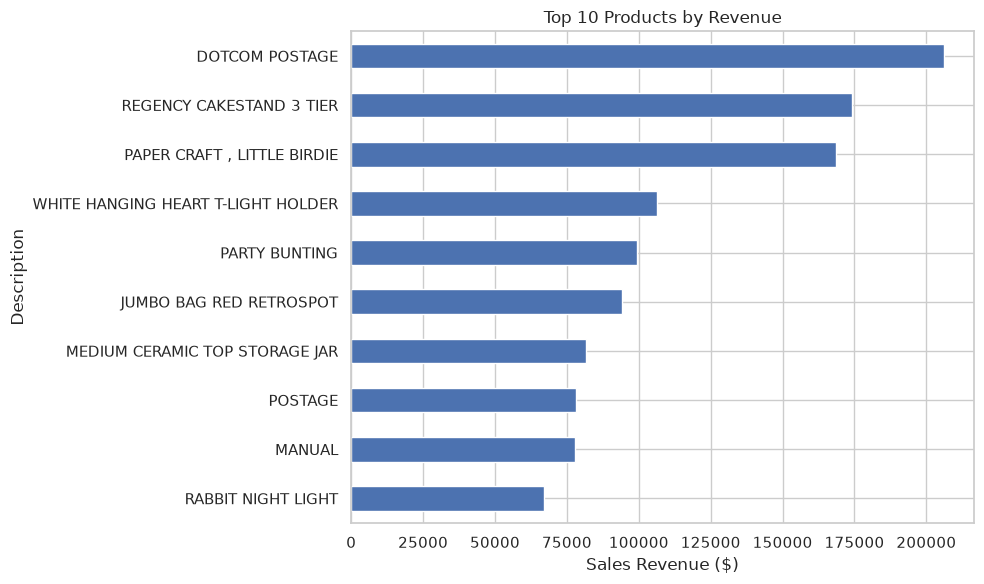

In [7]:
# STEP 4: AGGREGATIONS & VISUALIZATION

# 1. Top 10 Products by Revenue
top_products = df.groupby('Description')['sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind='barh').invert_yaxis()  # Inverted so highest is on top
plt.xlabel("Sales Revenue ($)")
plt.title("Top 10 Products by Revenue")
plt.tight_layout()
plt.savefig("Top_10_products.png", dpi=300)
plt.show()

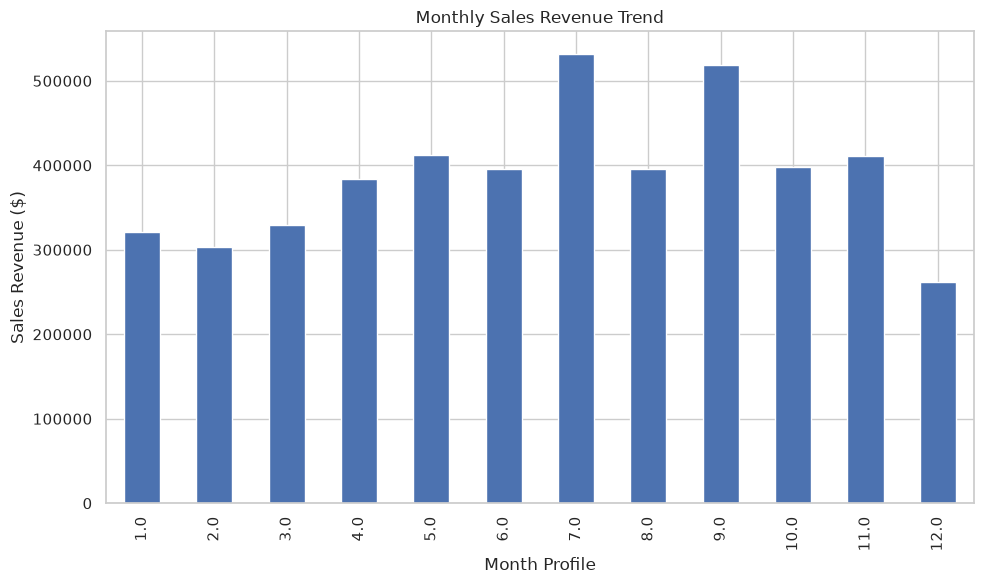

In [8]:
# 2. Monthly Trend Sales Distribution
monthly_sales = df.groupby('month')['sales'].sum()
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='bar')
plt.ylabel("Sales Revenue ($)")
plt.xlabel("Month Profile")
plt.title("Monthly Sales Revenue Trend")
plt.tight_layout()
plt.savefig("Monthly_sales.png", dpi=300)
plt.show()

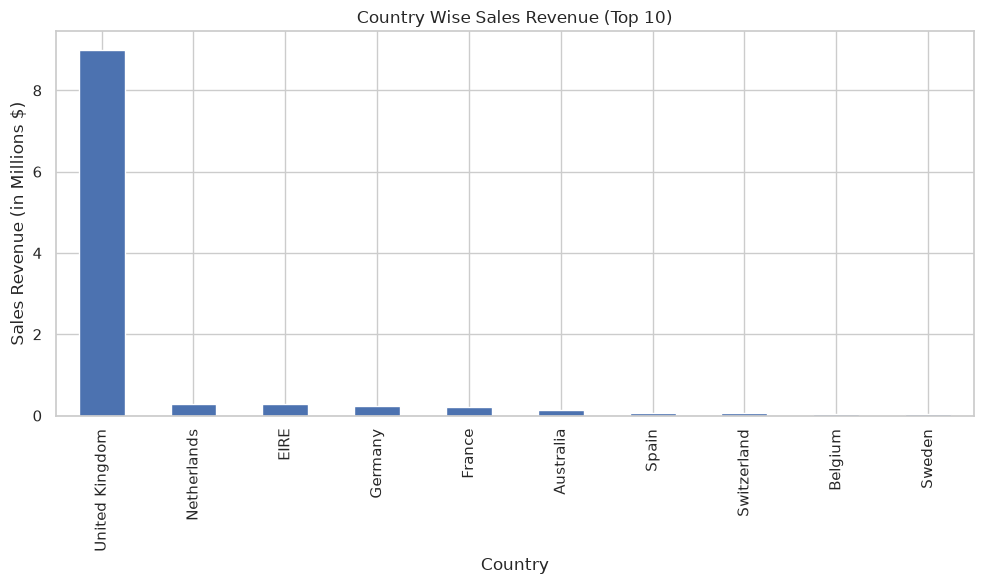

In [9]:
# 3. Top 10 Country Distribution
country_sales = df.groupby('Country')['sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
(country_sales / 1e6).plot(kind='bar')  # Scaled to Millions for visual clarity
plt.ylabel("Sales Revenue (in Millions $)")
plt.title("Country Wise Sales Revenue (Top 10)")
plt.tight_layout()
plt.savefig("Country_wise_sales.png", dpi=300)
plt.show()

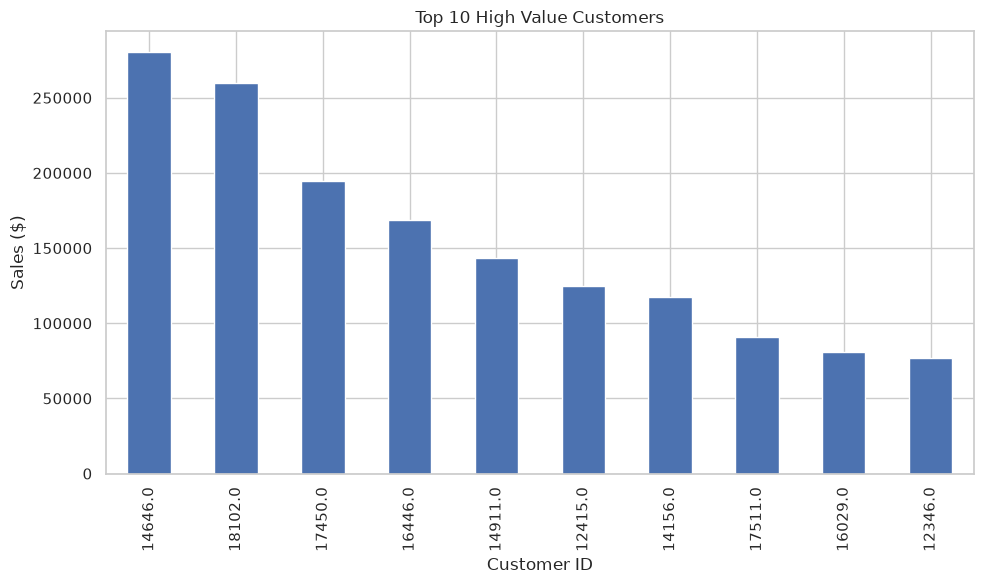

In [10]:
# 4. Top 10 Customers by Revenue Value
top_customers = df.groupby('Customer ID')['sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_customers.plot(kind='bar')
plt.ylabel("Sales ($)")
plt.title("Top 10 High Value Customers")
plt.tight_layout()
plt.savefig("Top_customers.png", dpi=300)
plt.show()


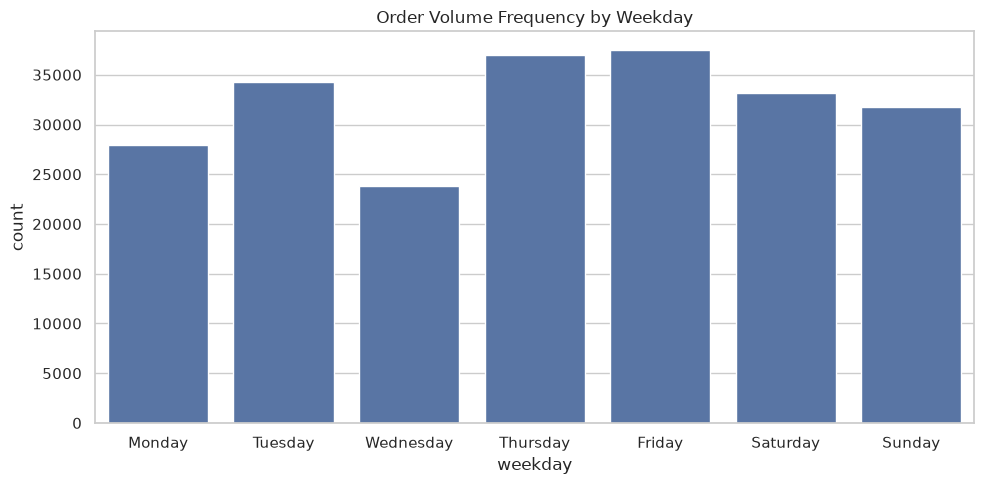

In [13]:
# 5. Order Frequency Analysis by Day of Week
plt.figure(figsize=(10, 5))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(x="weekday", data=df, order=weekday_order)
plt.title("Order Volume Frequency by Weekday")
plt.tight_layout()
plt.savefig("Weekely_Sales_Distribution.png", dpi=300)
plt.show()

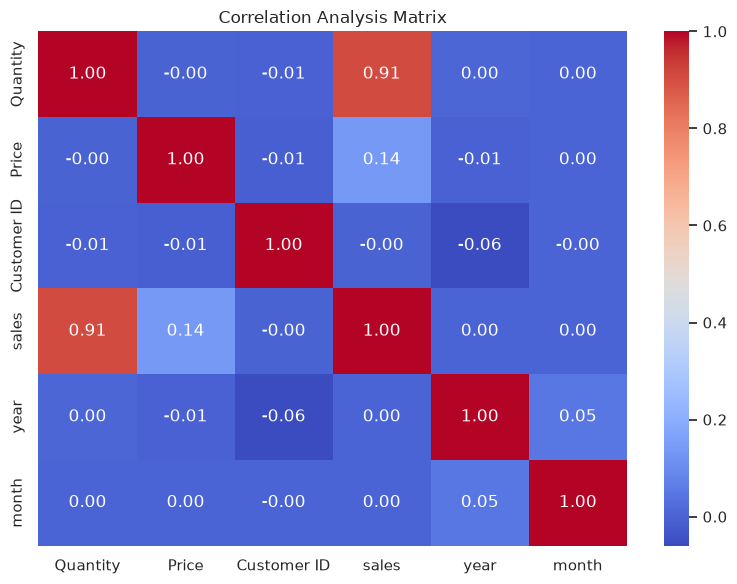

In [14]:
# 6. Numeric Matrix Feature Correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Analysis Matrix")
plt.tight_layout()
plt.savefig("Correaltion_Matrix.png", dpi=300)
plt.show()

In [71]:
np.median(df['sales'])

np.float64(11.9)

In [70]:
np.std(df["sales"])

np.float64(430.6773180839802)